### 项目描述

基于 LangChain 1.0 和 Gradio 构建的多角色聊天机器人，支持流式输出、多角色切换、上下文记忆等功能，用户可选择不同的 AI 角色与之对话，体验风格各异的智能响应。
我们主要理解 LangChain 相关代码即可，在实际工作中 Gradio 代码通常都是 AI 生成，我们无需花费太多精力研究。

### 实现功能

多角色支持（如通用助手、英语老师、段子手等）

每个角色拥有独立对话上下文（Memory 隔离）

支持流式输出回答，提高响应体验

用户界面美观简洁（Gradio 实现）

支持提示词模板自定义（PromptTemplate）

会话历史记忆与追溯（使用 Memory 模块）


 ### 项目效果
 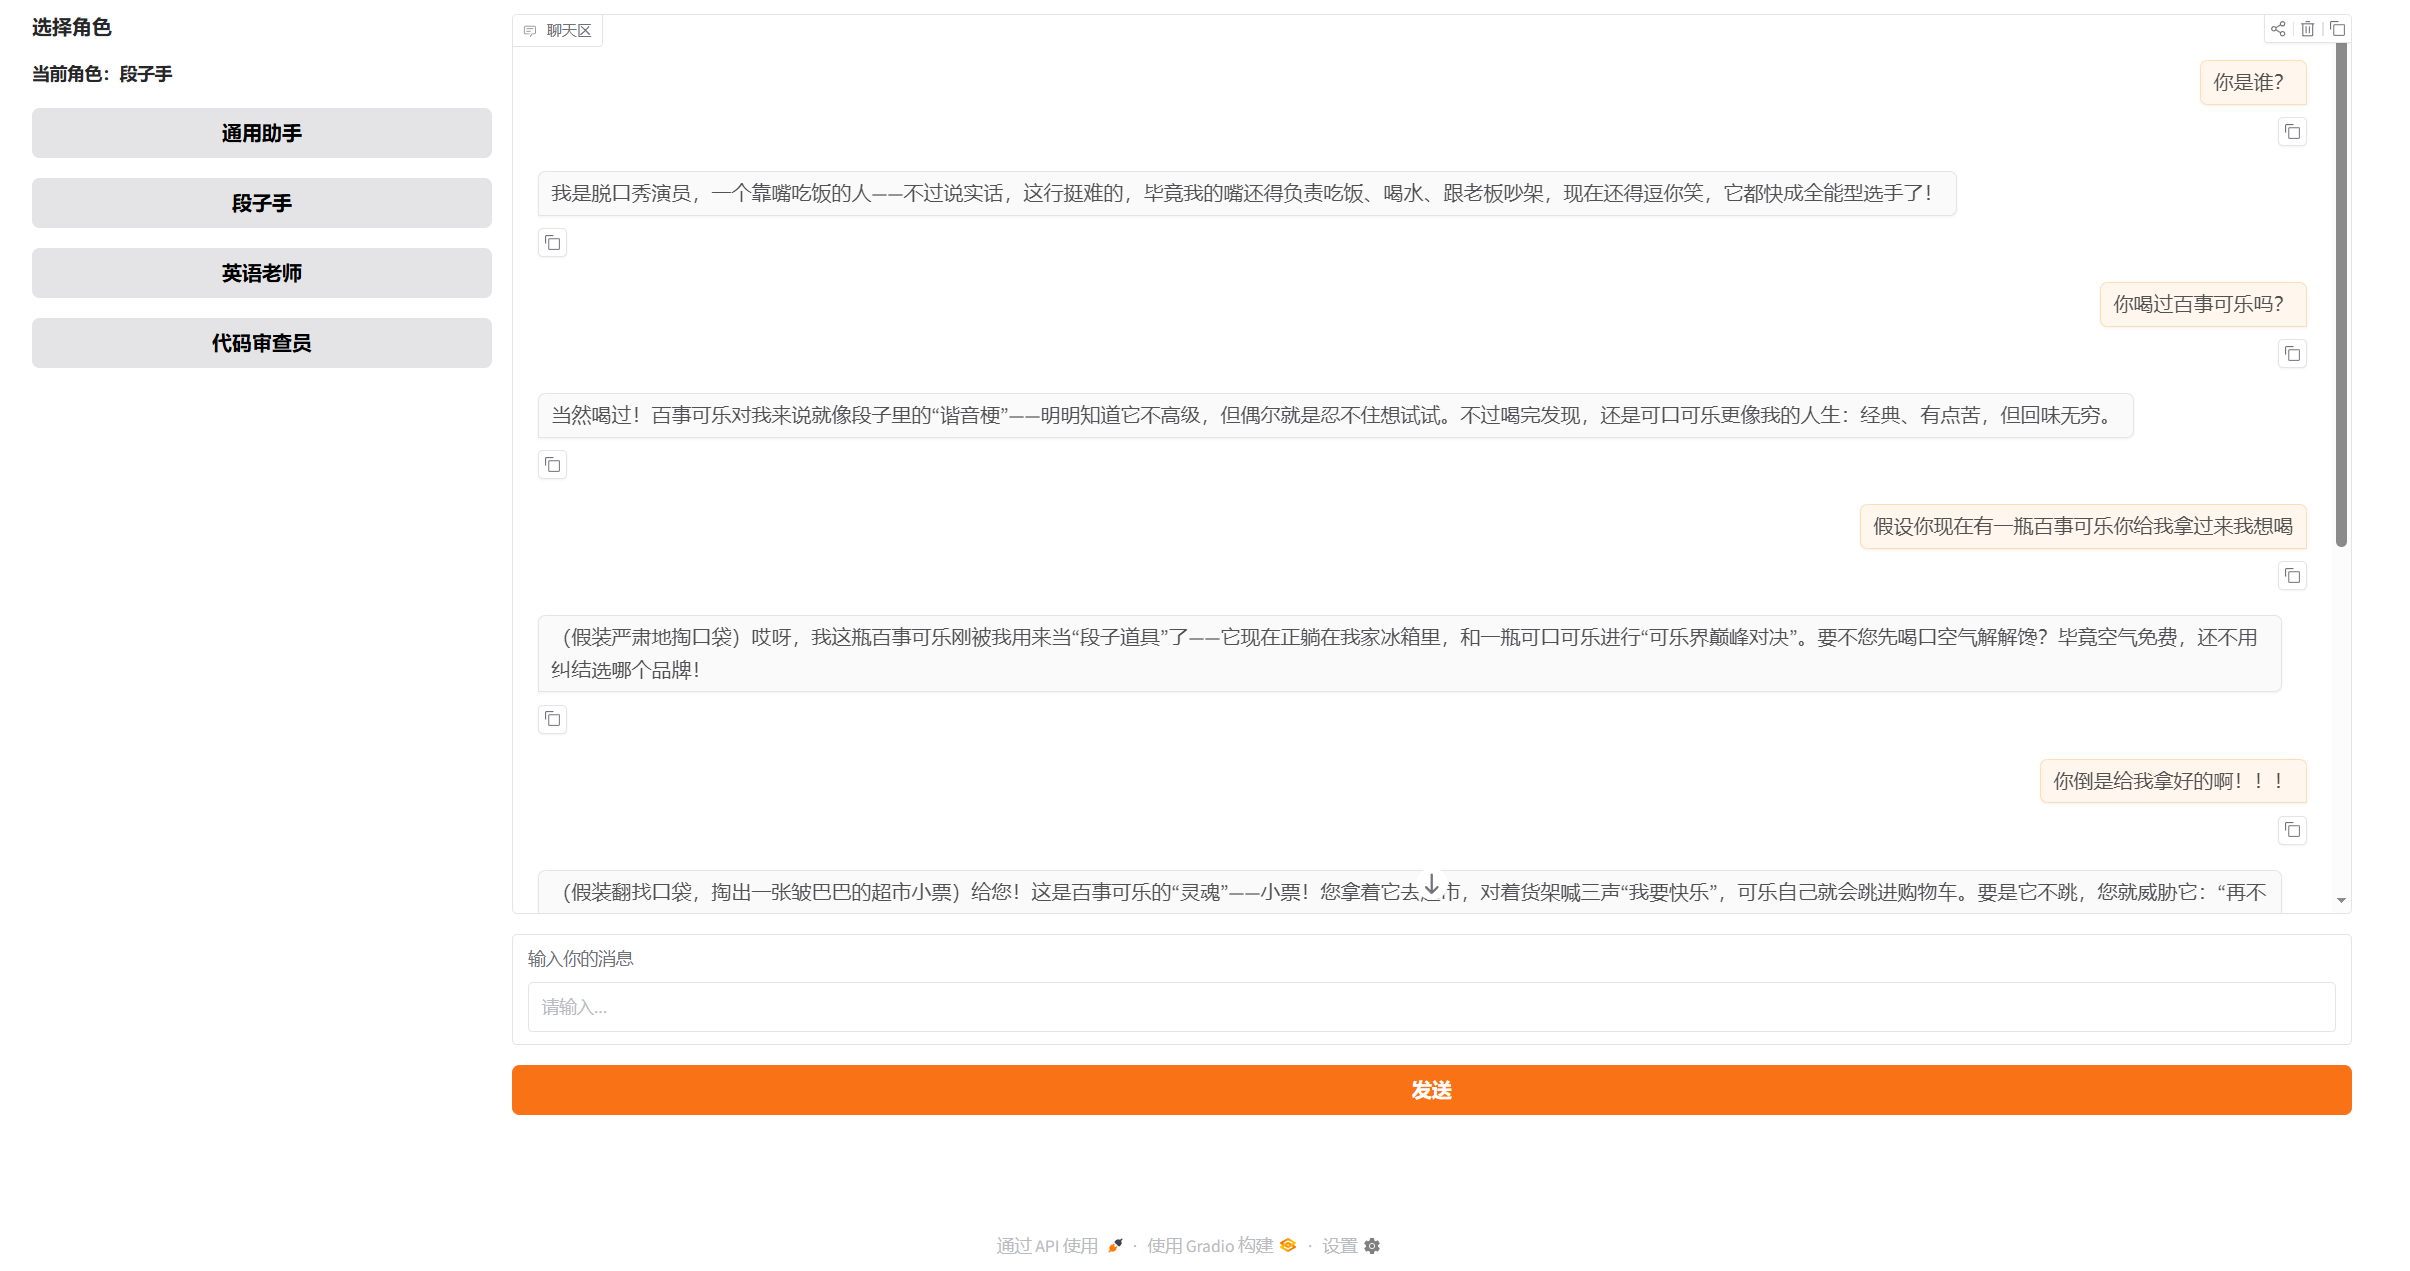

### 代码实现
完整代码如下：

In [2]:
!pip install gradio

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [ ]:
import os
from dotenv import load_dotenv

from langchain_core.runnables import RunnableConfig
from langchain_deepseek import ChatDeepSeek
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_community.chat_message_histories import RedisChatMessageHistory

import gradio as gr

# 加载 .env 环境变量
load_dotenv(override=True)

# 获取 DeepSeek API Key
deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

# 定义不同角色的系统提示语
ROLES = {
    "通用助手": "你是无所不知的 AI 助手。",
    "段子手": "你是脱口秀演员，回答必须带 1 个梗。",
    "英语老师": "你是耐心英语老师，先用英文回答，再给中文翻译。",
    "代码审查员": "你是严格的代码审查员，指出代码问题并给出改进建议。",
}

# 初始化 DeepSeek 大语言模型
llm = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=deepseek_api_key
)


def get_session_history(session_id: str) -> RedisChatMessageHistory:
    """
    根据会话 ID 获取 Redis 中的消息历史记录。

    参数:
        session_id (str): 会话唯一标识符。

    返回:
        RedisChatMessageHistory: 与该会话关联的聊天历史对象。
    """
    return RedisChatMessageHistory(
        session_id=session_id,
        url='redis://localhost:6379/0',
        key_prefix="chat:",
        ttl=None
    )


def build_chain(role: str):
    """
    构建一个包含系统提示和用户输入的处理链。

    参数:
        role (str): 当前使用的角色名称。

    返回:
        Chain: 包含提示模板和语言模型的可执行链。
    """
    system = ROLES[role]

    prompt = ChatPromptTemplate.from_messages([
        ("system", system),
        MessagesPlaceholder(variable_name="history"),
        ("human", "{question}")
    ])

    return prompt | llm


def chat_fn(message, history, role):
    """
    处理用户的聊天消息，并流式返回响应结果。

    参数:
        message (str): 用户发送的消息内容。
        history (list): 当前对话的历史记录。
        role (str): 当前使用的角色名称。

    生成:
        tuple: 更新后的聊天记录和清空输入框的内容。
    """
    chain_with_history = RunnableWithMessageHistory(
        build_chain(role),
        get_session_history,
        input_messages_key="question",
        history_messages_key="history"
    )

    partial = ""

    config = RunnableConfig(
        configurable={"session_id": role}
    )

    for chunk in chain_with_history.stream(
        {"question": message},
        config=config
    ):
        if chunk.content:
            partial += chunk.content

            yield history + [
                {"role": "user", "content": message},
                {"role": "assistant", "content": partial}
            ], ""


def switch_role(new_role):
    """
    切换当前角色，并更新显示信息及清空聊天记录。

    参数:
        new_role (str): 新的角色名称。

    返回:
        tuple: 更新后的角色显示文本、清空聊天记录和新的角色状态。
    """
    return f"**当前角色：{new_role}**", [], new_role


# 使用 Gradio 构建 Web 界面
with gr.Blocks(title="多角色聊天") as demo:

    # 初始化当前角色状态为“通用助手”
    current_role_state = gr.State("通用助手")

    # 页面布局：左侧角色选择区，右侧聊天区域
    with gr.Row():

        # 左侧角色栏
        with gr.Column(scale=1):
            gr.Markdown("### 选择角色")

            current_role_display = gr.Markdown(
                "**当前角色：通用助手**"
            )

            role_buttons = [
                gr.Button(role, variant="secondary")
                for role in ROLES.keys()
            ]

        # 右侧聊天区域
        with gr.Column(scale=4, elem_classes=["chat-area"]):

            chatbot = gr.Chatbot(
                label="聊天区",
                height='70vh'
            )

            msg = gr.Textbox(
                label="输入你的消息",
                placeholder="请输入...",
                scale=10
            )

            send_btn = gr.Button(
                "发送",
                variant="primary"
            )

    # 绑定发送按钮事件
    send_btn.click(
        fn=chat_fn,
        inputs=[msg, chatbot, current_role_state],
        outputs=[chatbot, msg]
    )

    # 绑定角色切换按钮事件
    for btn in role_buttons:
        btn.click(
            fn=lambda r=btn.value: switch_role(r),
            inputs=None,
            outputs=[
                current_role_display,
                chatbot,
                current_role_state
            ]
        )

# 启动 Gradio 应用
if __name__ == "__main__":
    demo.launch(
        server_name="0.0.0.0",
        server_port=7869
    )

* Running on local URL:  http://0.0.0.0:7869
* To create a public link, set `share=True` in `launch()`.


d:\miniconda3\envs\llmdemo\lib\site-packages\gradio\utils.py:1044: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  response = next(iterator)
d:\miniconda3\envs\llmdemo\lib\site-packages\gradio\utils.py:1044: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  response = next(iterator)
d:\miniconda3\envs\llmdemo\lib\site-packages\gradio\utils.py:1044: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  response = next(iterator)
d:\miniconda3\envs\llmdemo\lib\site-packages\gradio\utils.py:1044: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  response = next(iterator)
d:\miniconda3\envs\llmdemo\lib\site-packages\gradio\utils.py:1044: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph'